In [1]:
# Setting up the file path
import os
os.chdir('..')

In [ ]:
# Importing packages
import numpy as np
import torch
from itertools import product
from RL4CRN.iocrns.iocrn import IOCRN
from RL4CRN.iocrns.reactions import MassAction
from RL4CRN.utils.ic import IC
from RL4CRN.env2agent_interface.explicit_observer import ExplicitObserver
from RL4CRN.env2agent_interface.explicit_tensorizer import ExplicitTensorizer
from RL4CRN.iocrns.reaction_library import construct_mass_action_library
from RL4CRN.policies.add_reaction_by_index import AddReactionByIndex
from RL4CRN.agent2env_interface.library_actuator import LibraryActuator
from RL4CRN.environments.environment import Environment
from RL4CRN.environments.serial_environments import SerialEnvironments
from RL4CRN.env2agent_interface.explicit_observer import ExplicitObserver
from RL4CRN.env2agent_interface.explicit_tensorizer import ExplicitTensorizer
from RL4CRN.agent2env_interface.library_actuator import LibraryActuator
from RL4CRN.agent2env_interface.iocrn_stepper import IOCRNStepper
from RL4CRN.agents.reinforce_agent import REINFORCEAgent
from RL4CRN.rewards.deterministic import dynamic_tracking_error

In [3]:
# Construct the template CRN
r1 = MassAction([], ['Z_1'], ['u_1'], [1.0])
r2 = MassAction(['X_2'], [], ['u_2'], [4.5])
# r3 = MassAction(['Z_1'], ['Z_1', 'X_1'], [None], [0.2])
# r4 = MassAction(['X_1'], [], [None], [5.4])
# r5 = MassAction(['X_1'], ['X_1', 'X_2'], [None], [0.6])
# r6 = MassAction(['Z_1'], [], [None], [2.4])
# r7 = MassAction(['Z_2'], [], [None], [3.7])
crn_template = IOCRN([r1, r2], output_labels=['X_2'])
crn_template.compile()
num_inputs = crn_template.num_inputs
print('CRN template:')
print(crn_template)

CRN template:
Inputs: ['u_1', 'u_2'] 
Species: ['X_2', 'Z_1'] 
Output Species: ['X_2'] 
∅ ----> Z_1;  [MAK(1.0, u_1)]
X_2 ----> ∅;  [MAK(4.5, u_2)]


In [4]:
# Construct a list of initial conditions
species_labels = ['X_1', 'X_2', 'Z_1', 'Z_2']
ic = IC(species_labels, values= [
    [5, 6, 7, 8],
])
x0_list = ic.get_ic(crn_template)

# Construct a list of input scenarios
input_values = [1.0]
u_list = [np.array(u, dtype=np.float32) for u in product(input_values, repeat=crn_template.num_inputs)]
print(u_list)

# Construct the time horizon
time_horizon = np.linspace(0, 0.5, 1000, dtype=np.float32)

[array([1., 1.], dtype=float32)]


In [5]:
# Construct the reaction library
library = construct_mass_action_library(species_labels, 2)
crn_template.set_library_context(library)
print(crn_template.gather_reaction_IDs())
print('Reaction library:')
print(library)

[2, 28]
Reaction library:
Number of reactions: 211
R0: ∅ ----> X_1;  [MAK(None)]
R1: ∅ ----> X_2;  [MAK(None)]
R2: ∅ ----> Z_1;  [MAK(None)]
R3: ∅ ----> Z_2;  [MAK(None)]
R4: ∅ ----> X_1 + X_1;  [MAK(None)]
R5: ∅ ----> X_1 + X_2;  [MAK(None)]
R6: ∅ ----> X_1 + Z_1;  [MAK(None)]
R7: ∅ ----> X_1 + Z_2;  [MAK(None)]
R8: ∅ ----> X_2 + X_2;  [MAK(None)]
R9: ∅ ----> X_2 + Z_1;  [MAK(None)]
R10: ∅ ----> X_2 + Z_2;  [MAK(None)]
R11: ∅ ----> Z_1 + Z_1;  [MAK(None)]
R12: ∅ ----> Z_1 + Z_2;  [MAK(None)]
R13: ∅ ----> Z_2 + Z_2;  [MAK(None)]
R14: X_1 ----> ∅;  [MAK(None)]
R15: X_1 ----> X_2;  [MAK(None)]
R16: X_1 ----> Z_1;  [MAK(None)]
R17: X_1 ----> Z_2;  [MAK(None)]
R18: X_1 ----> X_1 + X_1;  [MAK(None)]
R19: X_1 ----> X_1 + X_2;  [MAK(None)]
R20: X_1 ----> X_1 + Z_1;  [MAK(None)]
R21: X_1 ----> X_1 + Z_2;  [MAK(None)]
R22: X_1 ----> X_2 + X_2;  [MAK(None)]
R23: X_1 ----> X_2 + Z_1;  [MAK(None)]
R24: X_1 ----> X_2 + Z_2;  [MAK(None)]
R25: X_1 ----> Z_1 + Z_1;  [MAK(None)]
R26: X_1 ----> Z_1 + Z_

In [6]:
# Build the environment
batch_size = 2
hall_of_fame_size = 1
logger = None
max_added_reactions = 2
crn_0 = crn_template.clone()
mult_env = SerialEnvironments([Environment(crn_0, max_added_reactions, logger=logger, logger_schedule=1) for _ in range(batch_size)], hall_of_fame_size=hall_of_fame_size, logger=logger)

In [7]:
# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


In [8]:
# Construct the environment-agent interface
observer = ExplicitObserver(library)
tensorizer = ExplicitTensorizer(device=device)

In [9]:
# Construct the observer and tensorizer
observer = ExplicitObserver(library)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
tensorizer = ExplicitTensorizer(device)

In [10]:
# Observe
observations = mult_env.observe(observer, tensorizer)
for i in range(len(observations)):
    reaction_multihot = observations[i, 0:len(library)]
    params_cross_multihot = observations[i, len(library):len(library)+library.get_num_parameters()]
    inputs_multihot = observations[i, len(library)+library.get_num_parameters():len(library)+library.get_num_parameters()*(num_inputs+1)]
    print(f'Environment {i}:')
    print(f'Structure (shape: {reaction_multihot.shape}):')
    print('Present reactions indices:', torch.where(reaction_multihot==1)[0])
    print(reaction_multihot)
    print('--------------')
    print(f'Parameters (shape: {params_cross_multihot.shape}):')
    print('Non-zero parameters indices:', torch.where(params_cross_multihot>0)[0])
    print(params_cross_multihot)
    print('--------------')
    print('Inputs (shape: {}):'.format(inputs_multihot.shape))
    print('Non-zero inputs indices:', torch.where(inputs_multihot>0)[0])
    print(inputs_multihot)
    print('==============')

Environment 0:
Structure (shape: torch.Size([211])):
Present reactions indices: tensor([ 2, 28], device='cuda:0')
tensor([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
      

In [ ]:
# Construct the Agent
width = 1024
depth = 5
deep_layer_size = 1024*10
learning_rate = 1e-4
entropy_scheduler = {                               # Entropy scheduler parameters
    'entropy_weight': 50.0, 
    'entropy_update_coefficient': 0.75, 
    'entropy_schedule': 5, 
    'minimum_entropy_weight': 50
}
risk_scheduler = {                                  # Risk scheduler parameters
    'risk': 0.95, 
    'risk_update': 0.0, 
    'max_risk': 1.0, 
    'risk_schedule': 20
}

encoder_attributes = {"hidden_size": width, "num_layers": depth}
structure_head_attributes = {"hidden_size": width, "num_layers": depth}
parameter_head_attributes = {"hidden_size": width, "num_layers": depth}
input_influence_head_attributes = {"hidden_size": width, "num_layers": depth}
policy = AddReactionByIndex(library, num_inputs, encoder_attributes, deep_layer_size, structure_head_attributes, parameter_head_attributes, input_influence_head_attributes, allow_input_influence=False, device=device)
agent = REINFORCEAgent(policy, allow_input_influence=False, logger=logger, learning_rate=learning_rate, entropy_scheduler=entropy_scheduler, risk_scheduler=risk_scheduler, device=device)

In [12]:
# Construct the agent-environment interface
actuator = LibraryActuator(library)
stepper = IOCRNStepper()

In [13]:
# Get action 
actions = agent.act(observations, actuator)
print(f'Actions (shape: {len(actions)}):')
for i in range(len(actions)):
    print(f'Environment {i}:')
    print(actions[i])

Actions (shape: 2):
Environment 0:
Z_1 + Z_1 ----> X_2 + Z_2;  [MAK(0.6302182674407959)]
Environment 1:
Z_2 + Z_2 ----> X_2 + Z_1;  [MAK(0.2779548168182373)]


In [14]:
# Update the environments
out = mult_env.step(actions, stepper)
for i in range(batch_size):
    print(f'Environment {i}:')
    print(mult_env.envs[i].state)
    print('IDs:')
    print(mult_env.envs[i].state.gather_reaction_IDs())
    print('-----------')

Environment 0:
Inputs: ['u_1', 'u_2'] 
Species: ['X_2', 'Z_1', 'Z_2'] 
Output Species: ['X_2'] 
∅ ----> Z_1;  [MAK(1.0, u_1)]
X_2 ----> ∅;  [MAK(4.5, u_2)]
Z_1 + Z_1 ----> X_2 + Z_2;  [MAK(0.6302182674407959)]
IDs:
[2, 28, 179]
-----------
Environment 1:
Inputs: ['u_1', 'u_2'] 
Species: ['X_2', 'Z_1', 'Z_2'] 
Output Species: ['X_2'] 
∅ ----> Z_1;  [MAK(1.0, u_1)]
X_2 ----> ∅;  [MAK(4.5, u_2)]
Z_2 + Z_2 ----> X_2 + Z_1;  [MAK(0.2779548168182373)]
IDs:
[2, 28, 206]
-----------


In [15]:
# Get rewards

# Construct the weights for the performance metric
N_t = 1000
w = np.ones(N_t)
w[(len(w)//5)*4:] = w[(len(w)//5)*4:]*2
w[:(len(w)//5)] = w[:(len(w)//5)]*0.25
w = w[np.newaxis, :]

# Construct the compute reward routine #TODO: use label of the input instead of its index
def compute_reward(state):
   r_list = [np.array([u[0]]) for u in u_list]
   x0_list = ic.get_ic(state)
   return dynamic_tracking_error(state, u_list, x0_list, time_horizon, r_list, w, norm=1, LARGE_NUMBER=1e4)

rewards = mult_env.get_reward(compute_reward)
print(rewards)

(np.float64(1.8286462900560045), np.float64(1.748416352327248))


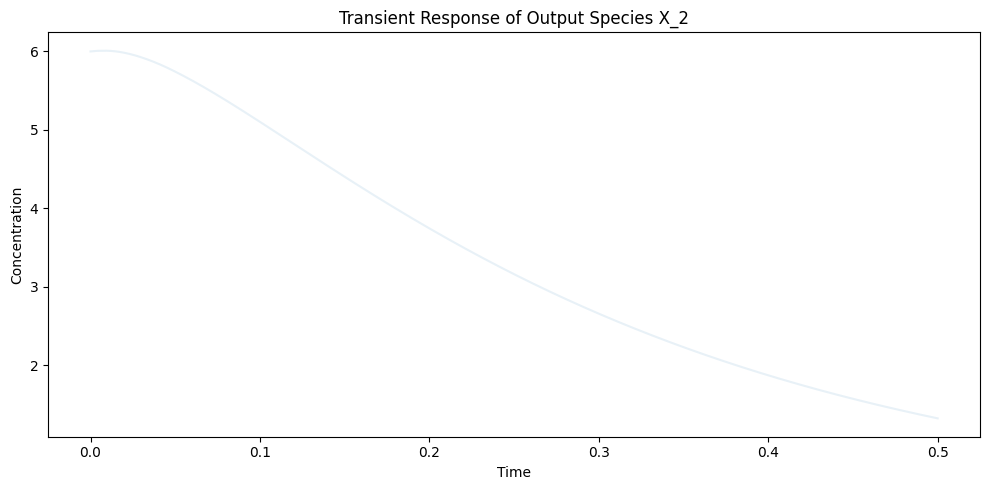

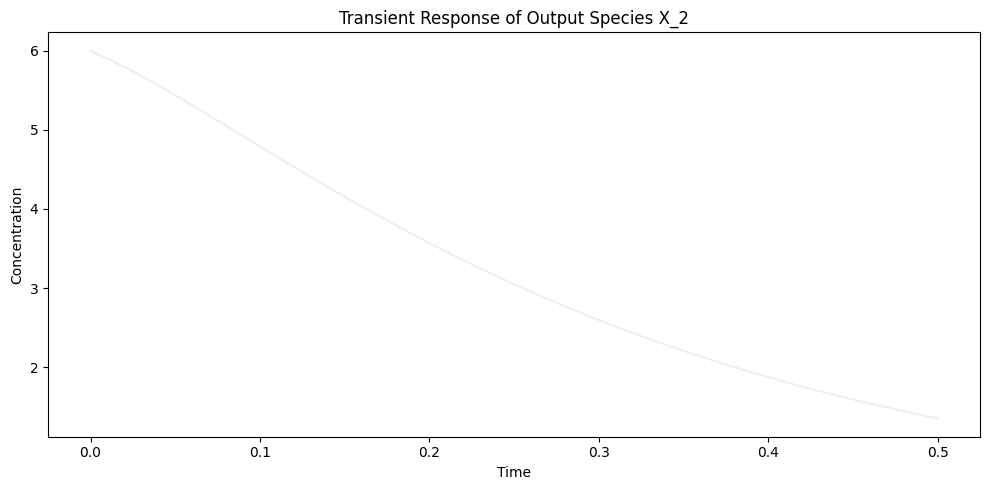

In [16]:
# Plot the responses
for i in range(batch_size):
    mult_env.envs[i].state.plot_transient_response()

In [17]:
# Update the agent
agent.update(rewards, step_iteration=1)
mult_env.reset()

In [18]:
# Observe
observations = mult_env.observe(observer, tensorizer)
for i in range(len(observations)):
    reaction_multihot = observations[i, 0:len(library)]
    params_cross_multihot = observations[i, len(library):len(library)+library.get_num_parameters()]
    inputs_multihot = observations[i, len(library)+library.get_num_parameters():len(library)+library.get_num_parameters()*(num_inputs+1)]
    print(f'Environment {i}:')
    print(f'Structure (shape: {reaction_multihot.shape}):')
    print('Present reactions indices:', torch.where(reaction_multihot==1)[0])
    print(reaction_multihot)
    print('--------------')
    print(f'Parameters (shape: {params_cross_multihot.shape}):')
    print('Non-zero parameters indices:', torch.where(params_cross_multihot>0)[0])
    print(params_cross_multihot)
    print('--------------')
    print('Inputs (shape: {}):'.format(inputs_multihot.shape))
    print('Non-zero inputs indices:', torch.where(inputs_multihot>0)[0])
    print(inputs_multihot)
    print('==============')

Environment 0:
Structure (shape: torch.Size([211])):
Present reactions indices: tensor([ 2, 28], device='cuda:0')
tensor([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
      

In [19]:
# Get action 
actions = agent.act(observations, actuator)
print(f'Actions (shape: {len(actions)}):')
for i in range(len(actions)):
    print(f'Environment {i}:')
    print(actions[i])

Actions (shape: 2):
Environment 0:
Z_1 ----> X_2;  [MAK(2.511665105819702)]
Environment 1:
X_1 + Z_2 ----> Z_2;  [MAK(0.4406009316444397)]


In [20]:
# Update the environments
out = mult_env.step(actions, stepper)
for i in range(batch_size):
    print(f'Environment {i}:')
    print(mult_env.envs[i].state)
    print('IDs:')
    print(mult_env.envs[i].state.gather_reaction_IDs())
    print('-----------')

Environment 0:
Inputs: ['u_1', 'u_2'] 
Species: ['X_2', 'Z_1'] 
Output Species: ['X_2'] 
∅ ----> Z_1;  [MAK(1.0, u_1)]
X_2 ----> ∅;  [MAK(4.5, u_2)]
Z_1 ----> X_2;  [MAK(2.511665105819702)]
IDs:
[2, 28, 44]
-----------
Environment 1:
Inputs: ['u_1', 'u_2'] 
Species: ['X_1', 'X_2', 'Z_1', 'Z_2'] 
Output Species: ['X_2'] 
∅ ----> Z_1;  [MAK(1.0, u_1)]
X_2 ----> ∅;  [MAK(4.5, u_2)]
X_1 + Z_2 ----> Z_2;  [MAK(0.4406009316444397)]
IDs:
[2, 28, 116]
-----------


In [21]:
# Get rewards
rewards = mult_env.get_reward(compute_reward)
print(rewards)

(np.float64(2.5876150986043234), np.float64(0.9327839601595286))


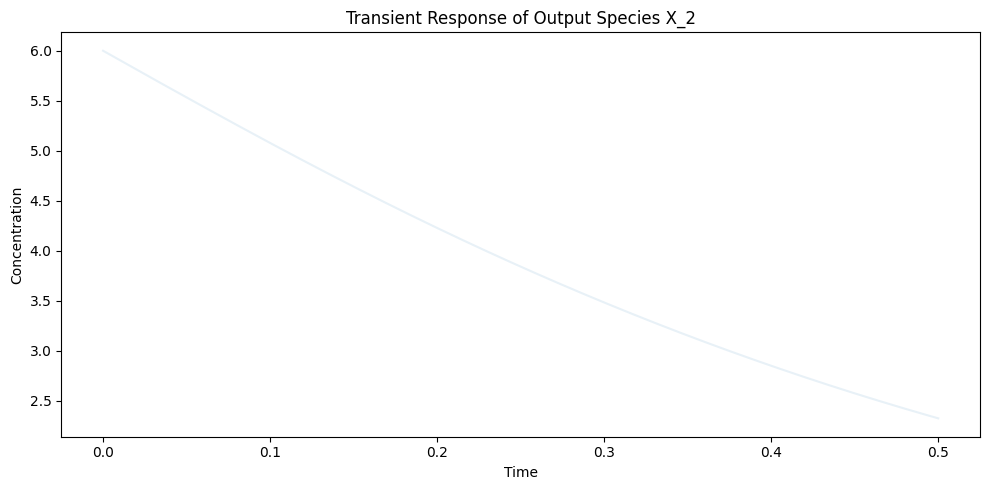

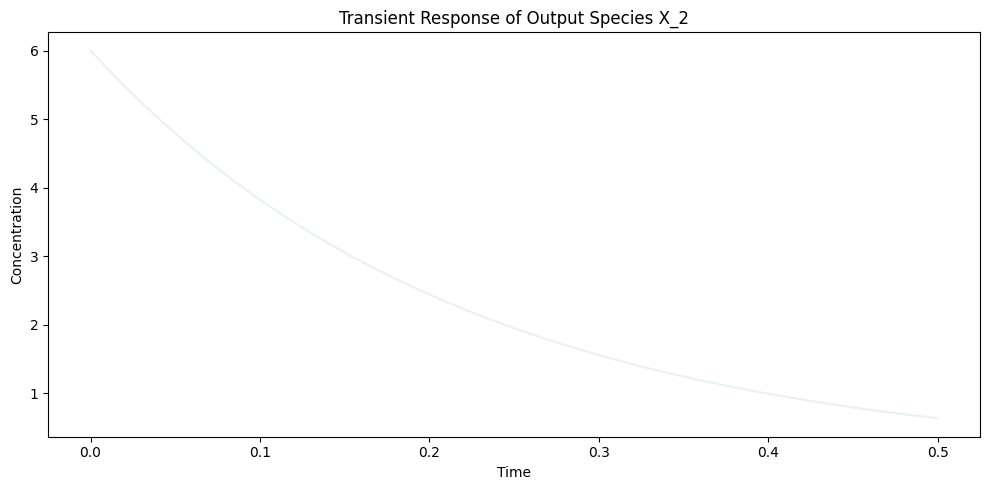

In [22]:
# Plot the responses
for i in range(batch_size):
    mult_env.envs[i].state.plot_transient_response()

In [23]:
print(mult_env.envs[0].state.last_task_info["trajectories"][0][:,-1])
print(mult_env.envs[0].state.last_task_info["initial conditions"])
print(mult_env.envs[0].state.last_task_info["inputs"])

[2.32459829 2.27494447]
[array([6, 7])]
[array([1., 1.], dtype=float32)]
